In [1]:
import os
import numpy as np
import random
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"✅ Random seeds set to {SEED}")
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ NumPy version: {np.__version__}")


import cv2
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import time
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt


✅ Random seeds set to 42
✅ TensorFlow version: 2.16.1
✅ NumPy version: 1.24.3


In [2]:
import os
import zipfile
import cv2
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split

ZIP_PATH = r"C:\Users\chery\Downloads\archive.zip"
EXTRACT_PATH = os.path.expanduser('~/Downloads/archive_extracted/')

print("Extracting archive...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print(f"Extracted to: {EXTRACT_PATH}")

BASE_PATH = EXTRACT_PATH
IMAGES_PATH = os.path.join(BASE_PATH, 'Images')
LABELS_PATH = os.path.join(BASE_PATH, 'Masks')

print(f"\n=== Checking extracted contents ===")
print(f"BASE_PATH: {BASE_PATH}")
print(f"Extracted folder exists: {os.path.exists(BASE_PATH)}")

if os.path.exists(BASE_PATH):
    contents = os.listdir(BASE_PATH)
    print(f"Contents of extracted folder: {contents}")

    print(f"Images folder exists: {os.path.exists(IMAGES_PATH)}")
    print(f"Masks folder exists: {os.path.exists(LABELS_PATH)}")
    
    if os.path.exists(IMAGES_PATH):
        image_files = os.listdir(IMAGES_PATH)
        print(f"Number of files in Images: {len(image_files)}")
        if image_files:
            print(f"Sample image files: {image_files[:5]}")
    
    if os.path.exists(LABELS_PATH):
        mask_files = os.listdir(LABELS_PATH)
        print(f"Number of files in Masks: {len(mask_files)}")
        if mask_files:
            print(f"Sample mask files: {mask_files[:5]}")

if not os.path.exists(IMAGES_PATH) or not os.path.exists(LABELS_PATH):
    print("\n=== Auto-detecting folder structure ===")
    for root, dirs, files in os.walk(BASE_PATH):
        for dir_name in dirs:
            dir_path = os.path.join(root, dir_name)
            files_count = len(os.listdir(dir_path))
            print(f"Found directory: {dir_path} ({files_count} files)")
            
            # Check if this looks like an images or masks folder
            if any(name in dir_name.lower() for name in ['image', 'train', 'data']):
                IMAGES_PATH = dir_path
                print(f"  → Using as IMAGES_PATH")
            elif any(name in dir_name.lower() for name in ['mask', 'label']):
                LABELS_PATH = dir_path
                print(f"  → Using as LABELS_PATH")

print(f"\nFinal paths:")
print(f"IMAGES_PATH: {IMAGES_PATH}")
print(f"LABELS_PATH: {LABELS_PATH}")

IMG_HEIGHT, IMG_WIDTH = 512, 512

def load_data(image_dir, mask_dir, img_size=(512, 512)):
    valid_ext = ('.tif', '.tiff', '.png', '.jpg', '.jpeg')

    image_paths = sorted([
        p for p in glob(os.path.join(image_dir, '*')) if p.lower().endswith(valid_ext)
    ])
    mask_paths = sorted([
        p for p in glob(os.path.join(mask_dir, '*')) if p.lower().endswith(valid_ext)
    ])

    print(f"Found {len(image_paths)} image files and {len(mask_paths)} mask files")

    images, masks = [], []

    for i, (img_path, mask_path) in enumerate(zip(image_paths, mask_paths)):
        if i % 100 == 0:  # Print progress every 100 files
            print(f"Processing {i}/{len(image_paths)}...")
            
        img = cv2.imread(img_path)
        if img is None:
            print(f"[WARNING] Could not load image: {img_path}")
            continue

        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"[WARNING] Could not load mask: {mask_path}")
            continue

        mask = cv2.resize(mask, img_size)
        mask = np.expand_dims(mask, axis=-1)
        mask = (mask > 127).astype(np.float32)

        images.append(img)
        masks.append(mask)

    print(f"✅ Successfully loaded {len(images)} images and {len(masks)} masks.")
    return np.array(images), np.array(masks)

print("\n=== Loading data ===")
X, Y = load_data(IMAGES_PATH, LABELS_PATH)

if len(X) > 0 and len(Y) > 0:
    from sklearn.model_selection import train_test_split

    train_size = 0.8
    test_size = 1 - train_size

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, 
        train_size=train_size,
        test_size=test_size,
        random_state=42  
    )

    print(f"X_train shape: {X_train.shape}")
    print(f"Y_train shape: {Y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"Y_test shape: {Y_test.shape}")
else:
    print("No data loaded! Check the file paths and folder structure.")

Extracting archive...
Extracted to: C:\Users\chery/Downloads/archive_extracted/

=== Checking extracted contents ===
BASE_PATH: C:\Users\chery/Downloads/archive_extracted/
Extracted folder exists: True
Contents of extracted folder: ['Images', 'Masks']
Images folder exists: True
Masks folder exists: True
Number of files in Images: 116
Sample image files: ['ytma10_010704_benign1_ccd.tif', 'ytma10_010704_benign1_ccd.tif.xml', 'ytma10_010704_benign2_ccd.tif', 'ytma10_010704_benign2_ccd.tif.xml', 'ytma10_010704_benign3_ccd.tif']
Number of files in Masks: 116
Sample mask files: ['ytma10_010704_benign1.TIF', 'ytma10_010704_benign1.TIF.xml', 'ytma10_010704_benign2.TIF', 'ytma10_010704_benign2.TIF.xml', 'ytma10_010704_benign3.TIF']

Final paths:
IMAGES_PATH: C:\Users\chery/Downloads/archive_extracted/Images
LABELS_PATH: C:\Users\chery/Downloads/archive_extracted/Masks

=== Loading data ===
Found 58 image files and 58 mask files
Processing 0/58...
✅ Successfully loaded 58 images and 58 masks.
X_

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
import time

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def focal_loss(alpha=0.25, gamma=2.0):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        
        cross_entropy = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        
        weight = (alpha * y_true * K.pow(1 - y_pred, gamma) + 
                 (1 - alpha) * (1 - y_true) * K.pow(y_pred, gamma))
        
        loss = weight * cross_entropy
        return K.mean(loss)
    
    return focal_loss_fixed


def combined_dice_bce_loss(y_true, y_pred, dice_weight=0.5, bce_weight=0.5):
    dice = dice_loss(y_true, y_pred)
    
    y_pred_clipped = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
    bce = -K.mean(y_true * K.log(y_pred_clipped) + 
                  (1 - y_true) * K.log(1 - y_pred_clipped))
    
    return dice_weight * dice + bce_weight * bce

def weighted_bce_loss(pos_weight=10.0):

    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        
        bce = -(pos_weight * y_true * K.log(y_pred) + 
                (1 - y_true) * K.log(1 - y_pred))
        
        return K.mean(bce)
    
    return loss


def plot_training_history(history):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = [
        ('loss', 'Loss'),
        ('accuracy', 'Accuracy'),
        ('recall', 'Recall (Sensitivity)'),
        ('precision', 'Precision')
    ]
    
    for ax, (metric, title) in zip(axes.flat, metrics):
        ax.plot(history.history[metric], label=f'Training {title}')
        ax.plot(history.history[f'val_{metric}'], label=f'Validation {title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.set_title(f'{title} over epochs')
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    

    for metric, title in metrics:
        train_val = history.history[metric][-1]
        val_val = history.history[f'val_{metric}'][-1]
        print(f"{title:<20} {train_val:<15.4f} {val_val:<15.4f}")

In [4]:
def create_simple_CNN_model(input_shape, receptive_field, n_filters, 
                           n_layers, eta, lmbd,
                           activation='relu',
                           padding='same',
                           regularizer='l2',
                           optimizer_name='adam',
                           loss_function='bce'):

    model = Sequential()
    
    if regularizer == 'l2':
        reg = regularizers.l2(lmbd)
    elif regularizer == 'l1':
        reg = regularizers.l1(lmbd)
    elif regularizer == 'l1_l2':
        reg = regularizers.l1_l2(l1=lmbd, l2=lmbd)
    else:
        reg = None
    
    for i in range(n_layers):
        filters = n_filters * (2 ** i)
        
        if i == 0:
            model.add(layers.Conv2D(filters, (receptive_field, receptive_field), 
                                    input_shape=input_shape, padding=padding,
                                    activation=activation, 
                                    kernel_regularizer=reg))
        else:
            model.add(layers.Conv2D(filters, (receptive_field, receptive_field), 
                                    padding=padding, activation=activation, 
                                    kernel_regularizer=reg))
        
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    for i in range(n_layers - 1, -1, -1):
        filters = n_filters * (2 ** i)
        
        model.add(layers.Conv2DTranspose(filters, (receptive_field, receptive_field), 
                                         strides=(2, 2), padding=padding, 
                                         activation=activation))
    
    model.add(layers.Conv2D(1, (1, 1), activation='sigmoid'))

    if optimizer_name.lower() == 'adam':
        opt = optimizers.Adam(learning_rate=eta)
    elif optimizer_name.lower() == 'sgd':
        opt = optimizers.SGD(learning_rate=eta)
    elif optimizer_name.lower() == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=eta)
    else:
        opt = optimizers.Adam(learning_rate=eta)  # default
    
    if isinstance(loss_function, str):
        if loss_function in ['bce', 'binary_crossentropy']:
            loss = 'binary_crossentropy'
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'dice':
            loss = dice_loss
            metrics = ['accuracy', dice_coefficient,
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'focal_high_recall':
            loss = focal_loss(alpha=0.75, gamma=2.0)
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function in ['combined', 'combined_dice_bce_loss']:  
            loss = combined_dice_bce_loss
            metrics = ['accuracy', dice_coefficient,
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'weighted_bce':
            loss = weighted_bce_loss(pos_weight=10.0) 
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        

    
    model.compile(loss=loss, optimizer=opt, metrics=metrics)
    
    return model

In [5]:
!pip install keras-tuner


Your dataset stats:
  X_train: (46, 512, 512, 3)
  Y_train: (46, 512, 512, 1)
  X_test:  (12, 512, 512, 3)
  Y_test:  (12, 512, 512, 1)

Configuration:
  Bootstraps: 10
  Epochs: 20
  Batch size: 4
MEMORY-OPTIMIZED BIAS-VARIANCE ANALYSIS
Dataset size: 46 training, 12 test
Configuration: 10 bootstraps, 20 epochs
Test sequence: ['n_layers', 'n_filters']

Estimated time: ~16.7 hours
Start time: 04:13:26

TEST 1/2: N_LAYERS
TESTING: N_LAYERS
Values: [1, 2, 3, 4, 5]
Bootstraps: 10, Epochs: 20
Using 8/12 test samples for predictions

--- n_layers = 1 (1/5) ---
  Bootstrap 1/10...WARNING:tensorflow:From C:\Users\chery\anaconda3\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

 (135.6s, ~20.3min remaining)
  Bootstrap 2/10... (138.1s, ~18.2min remaining)
  Bootstrap 3/10... (111.2s, ~15.0min remaining)
  Bootstrap 4/10... (114.3s, ~12.5min remaining)
  Bootstrap 5/10... (109.5s, 

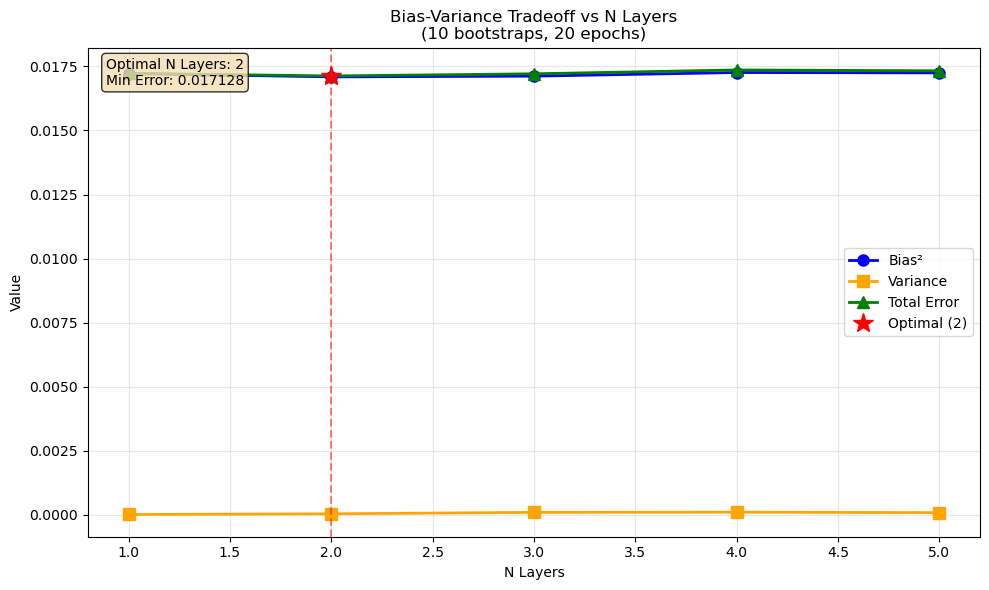


 Optimal n_layers: 2
  Bias²: 0.017092
  Variance: 0.000036
  Error: 0.017128

----------------------------------------
Pausing for 10 seconds to clear memory...
----------------------------------------

TEST 2/2: N_FILTERS
Using optimal n_layers = 2 from previous test
TESTING: N_FILTERS
Values: [8, 16, 32, 64, 128]
Bootstraps: 10, Epochs: 20
Using 8/12 test samples for predictions

--- n_filters = 8 (1/5) ---
  Bootstrap 1/10... (36.0s, ~5.4min remaining)
  Bootstrap 2/10... (36.4s, ~4.8min remaining)
  Bootstrap 3/10... (36.5s, ~4.2min remaining)
  Bootstrap 4/10... (36.2s, ~3.6min remaining)
  Bootstrap 5/10... (36.3s, ~3.0min remaining)
  Bootstrap 6/10... (36.5s, ~2.4min remaining)
  Bootstrap 7/10... (37.0s, ~1.8min remaining)
  Bootstrap 8/10... (36.9s, ~1.2min remaining)
  Bootstrap 9/10... (36.5s, ~0.6min remaining)
  Bootstrap 10/10... (37.7s, ~0.0min remaining)
  Results: Bias²=0.017397, Variance=0.000060, Error=0.017456
  Successful bootstraps: 10/10
  Time for this value:

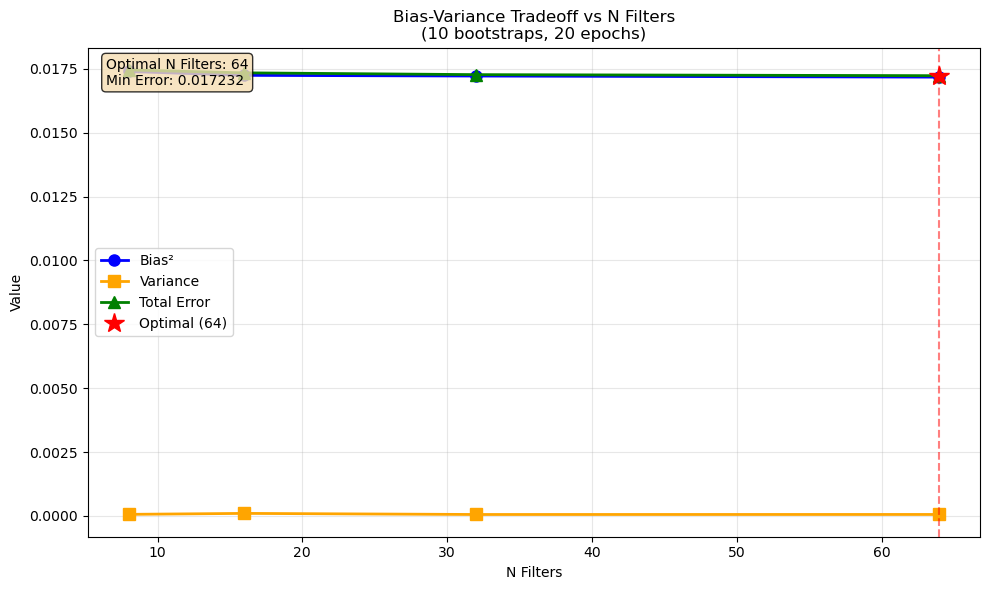


 Optimal n_filters: 64
  Bias²: 0.017176
  Variance: 0.000056
  Error: 0.017232
ANALYSIS COMPLETE!
End time: 09:03:00

OPTIMAL HYPERPARAMETERS FOUND:
----------------------------------------
n_layers        = 2
n_filters       = 64

 Optimal parameters saved to 'optimal_hyperparameters.txt'
SUMMARY FILES:
CSV files:
  n_layers_bias_variance_10bootstraps.csv
  n_filters_bias_variance_10bootstraps.csv

Plot files:
  n_layers_bias_variance.png
  n_filters_bias_variance.png


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
import tensorflow as tf
import gc
import time
import warnings
warnings.filterwarnings('ignore')

BOOTSTRAP_RUNS = 10      
EPOCHS = 20             
BATCH_SIZE = 4          

TEST_SEQUENCE = [
    {
        'name': 'n_layers',
        'values': [1, 2, 3, 4, 5],
        'fixed_params': {
            "n_filters": 32,
            "receptive_field": 3,
            "eta": 1e-3,
            "lmbd": 1e-5,
            "activation": "relu",
            "padding": "same",
            "regularizer": "l2",
            "optimizer_name": "adam",
            "loss_function='weighted_bce"
        }
    },
    {
        'name': 'n_filters',
        'values': [8, 16, 32, 64],
        'fixed_params': {
            "n_layers": 3,  
            "receptive_field": 3,
            "eta": 1e-3,
            "lmbd": 1e-5,
            "activation": "relu",
            "padding": "same",
            "regularizer": "l2",
            "optimizer_name": "adam",
            "loss_function='weighted_bce"
        }
    }
]

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_bias_variance_memory_efficient(predictions_list, y_true):
    first_pred = predictions_list[0]
    y_true_flat = y_true.flatten()
    
    sum_pred = np.zeros_like(first_pred.flatten(), dtype=np.float32)
    sum_sq_pred = np.zeros_like(first_pred.flatten(), dtype=np.float32)

    for i, pred in enumerate(predictions_list):
        pred_flat = pred.flatten().astype(np.float32)
        sum_pred += pred_flat
        sum_sq_pred += pred_flat ** 2

        predictions_list[i] = None
    
    n_runs = len(predictions_list)

    mean_pred = sum_pred / n_runs
    bias2 = mse(y_true_flat, mean_pred)

    variance = np.mean(sum_sq_pred / n_runs - mean_pred ** 2)

    error = bias2 + variance
    
    return bias2, variance, error

def run_single_hyperparameter_test(param_config, X_train, Y_train, X_test, Y_test):
    param_name = param_config['name']
    param_values = param_config['values']
    fixed_params = param_config['fixed_params']
    
    print(f"TESTING: {param_name.upper()}")
    print(f"Values: {param_values}")
    print(f"Bootstraps: {BOOTSTRAP_RUNS}, Epochs: {EPOCHS}")
    
    results = []
    start_time_total = time.time()
    
    if len(X_test) > 8:
        test_indices = np.random.choice(len(X_test), 8, replace=False)
        X_test_sub = X_test[test_indices]
        Y_test_sub = Y_test[test_indices]
    else:
        X_test_sub = X_test
        Y_test_sub = Y_test
    
    print(f"Using {len(X_test_sub)}/{len(X_test)} test samples for predictions")
    
    for i, param_value in enumerate(param_values):
        print(f"\n--- {param_name} = {param_value} ({i+1}/{len(param_values)}) ---")
        start_param_time = time.time()
        
        bootstrap_predictions = []
        bootstrap_durations = []
        
        for b in range(BOOTSTRAP_RUNS):
            print(f"  Bootstrap {b+1}/{BOOTSTRAP_RUNS}...", end="")
            start_bootstrap = time.time()

            Xb, Yb = resample(X_train, Y_train, random_state=b)

            model_params = fixed_params.copy()
            model_params[param_name] = param_value
            
            try:
                model = create_simple_CNN_model(
                    input_shape=X_train.shape[1:],
                    **model_params
                )
                
                history = model.fit(
                    Xb, Yb,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_split=0.2,
                    verbose=0,
                    callbacks=[
                        tf.keras.callbacks.EarlyStopping(
                            monitor='val_loss',
                            patience=4,
                            restore_best_weights=True,
                            verbose=0
                        )
                    ]
                )

                pred = model.predict(X_test_sub, batch_size=2, verbose=0)
                bootstrap_predictions.append(pred.astype(np.float16))

                actual_epochs = len(history.history['loss'])
                if actual_epochs < EPOCHS:
                    print(f" [stopped early at epoch {actual_epochs}]", end="")
                
            except Exception as e:
                print(f"\n  Error in bootstrap {b+1}: {str(e)[:50]}...")
                continue
            
            finally:
                del model
                tf.keras.backend.clear_session()
                gc.collect()
            
            bootstrap_duration = time.time() - start_bootstrap
            bootstrap_durations.append(bootstrap_duration)
            
            if len(bootstrap_durations) > 0:
                avg_time = np.mean(bootstrap_durations)
                remaining = avg_time * (BOOTSTRAP_RUNS - (b+1))
                print(f" ({bootstrap_duration:.1f}s, ~{remaining/60:.1f}min remaining)")
            else:
                print(f" ({bootstrap_duration:.1f}s)")

        if len(bootstrap_predictions) >= 3:
            bias2, variance, error = compute_bias_variance_memory_efficient(
                bootstrap_predictions, Y_test_sub
            )
            
            results.append({
                param_name: param_value,
                'bias2': bias2,
                'variance': variance,
                'error': error,
                'successful_bootstraps': len(bootstrap_predictions)
            })
            
            print(f"  Results: Bias²={bias2:.6f}, Variance={variance:.6f}, Error={error:.6f}")
            print(f"  Successful bootstraps: {len(bootstrap_predictions)}/{BOOTSTRAP_RUNS}")
        else:
            print(f"  Not enough successful bootstraps ({len(bootstrap_predictions)})")
        
        del bootstrap_predictions
        gc.collect()
        
        param_duration = time.time() - start_param_time
        print(f"  Time for this value: {param_duration/60:.1f} minutes")
    
    if results:
        df = pd.DataFrame(results)
        filename = f"{param_name}_bias_variance_{BOOTSTRAP_RUNS}bootstraps.csv"
        df.to_csv(filename, index=False)
        
        total_duration = time.time() - start_time_total
        print(f"\n {param_name} test complete!")
        print(f" Results saved to: {filename}")
        print(f" Total time: {total_duration/60:.1f} minutes")
        
        return df
    else:
        print(f"\n No valid results for {param_name}")
        return None

def plot_bias_variance_simple(df, param_name):
    plt.figure(figsize=(10, 6))

    plt.plot(df[param_name], df['bias2'], 'o-', label='Bias²', 
             linewidth=2, markersize=8, color='blue')
    plt.plot(df[param_name], df['variance'], 's-', label='Variance', 
             linewidth=2, markersize=8, color='orange')
    plt.plot(df[param_name], df['error'], '^-', label='Total Error', 
             linewidth=2, markersize=8, color='green')

    optimal_idx = df['error'].idxmin()
    optimal_value = df.loc[optimal_idx, param_name]
    optimal_error = df.loc[optimal_idx, 'error']
    
    plt.axvline(x=optimal_value, color='red', linestyle='--', alpha=0.5)
    plt.plot(optimal_value, optimal_error, 'r*', 
             markersize=15, label=f'Optimal ({optimal_value})')
  
    param_label = param_name.replace('_', ' ').title()
    plt.xlabel(param_label)
    plt.ylabel('Value')
    plt.title(f'Bias-Variance Tradeoff vs {param_label}\n({BOOTSTRAP_RUNS} bootstraps, {EPOCHS} epochs)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.text(0.02, 0.98, 
             f'Optimal {param_label}: {optimal_value}\nMin Error: {optimal_error:.6f}',
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()

    plt.savefig(f'{param_name}_bias_variance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return optimal_value



def run_complete_analysis():
    print("MEMORY-OPTIMIZED BIAS-VARIANCE ANALYSIS")
    print(f"Dataset size: {X_train.shape[0]} training, {X_test.shape[0]} test")
    print(f"Configuration: {BOOTSTRAP_RUNS} bootstraps, {EPOCHS} epochs")
    print(f"Test sequence: {[test['name'] for test in TEST_SEQUENCE]}")

    total_values = sum(len(test['values']) for test in TEST_SEQUENCE)
    estimated_minutes = total_values * BOOTSTRAP_RUNS * EPOCHS * 0.5  
    print(f"\nEstimated time: ~{estimated_minutes/60:.1f} hours")
    print(f"Start time: {time.strftime('%H:%M:%S')}")
    
    optimal_values = {}
    all_results = {}
 
    for i, test_config in enumerate(TEST_SEQUENCE):
        print(f"\n{'='*80}")
        print(f"TEST {i+1}/{len(TEST_SEQUENCE)}: {test_config['name'].upper()}")
        print('='*80)
 
        for param_name, optimal_value in optimal_values.items():
            if param_name in test_config['fixed_params']:
                test_config['fixed_params'][param_name] = optimal_value
                print(f"Using optimal {param_name} = {optimal_value} from previous test")

        df = run_single_hyperparameter_test(
            test_config,
            X_train, Y_train,
            X_test, Y_test
        )
        
        if df is not None:
            all_results[test_config['name']] = df

            optimal_value = plot_bias_variance_simple(df, test_config['name'])
            optimal_values[test_config['name']] = optimal_value

            optimal_row = df.loc[df['error'].idxmin()]
            print(f"\n Optimal {test_config['name']}: {optimal_value}")
            print(f"  Bias²: {optimal_row['bias2']:.6f}")
            print(f"  Variance: {optimal_row['variance']:.6f}")
            print(f"  Error: {optimal_row['error']:.6f}")
 
            if i < len(TEST_SEQUENCE) - 1:
                print("\n" + "-"*40)
                print("Pausing for 10 seconds to clear memory...")
                print("-"*40)
                time.sleep(10)
                gc.collect()

    print("ANALYSIS COMPLETE!")
    print("="*80)
    print(f"End time: {time.strftime('%H:%M:%S')}")
    
    if optimal_values:
        print("\nOPTIMAL HYPERPARAMETERS FOUND:")
        print("-"*40)
        for param_name, optimal_value in optimal_values.items():
            print(f"{param_name:15} = {optimal_value}")

        with open('optimal_hyperparameters.txt', 'w') as f:
            f.write("Optimal Hyperparameters:\n")
            f.write("="*40 + "\n")
            for param_name, optimal_value in optimal_values.items():
                f.write(f"{param_name}: {optimal_value}\n")
        
        print(f"\n Optimal parameters saved to 'optimal_hyperparameters.txt'")
    

    print("SUMMARY FILES:")
    print("CSV files:")
    for test in TEST_SEQUENCE:
        filename = f"{test['name']}_bias_variance_{BOOTSTRAP_RUNS}bootstraps.csv"
        if os.path.exists(filename):
            print(f"  {filename}")
    
    print("\nPlot files:")
    for test in TEST_SEQUENCE:
        filename = f"{test['name']}_bias_variance.png"
        if os.path.exists(filename):
            print(f"  {filename}")
    
    return all_results, optimal_values

print("\nYour dataset stats:")
print(f"  X_train: {X_train.shape}")
print(f"  Y_train: {Y_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Y_test:  {Y_test.shape}")
print("\nConfiguration:")
print(f"  Bootstraps: {BOOTSTRAP_RUNS}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")

all_results, optimal_values = run_complete_analysis()

Increasing the number of filters from 8 to 64 gradually reduced the bias, hence decreasing the total error. The optimal number of filters is 64, but improvements beyond 32 were marginal. This suggests that additional representational capacity helps, but the benefit plateaus as the model remains bias-dominated.

A moderate depth of 2 convolutional layers produced the lowest bias and total error. Both shallower (1 layer) and deeper architectures (3–5 layers) resulted in higher bias.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
import tensorflow as tf
import gc
import time
import warnings
warnings.filterwarnings('ignore')

BOOTSTRAP_RUNS = 10      
EPOCHS = 20             
BATCH_SIZE = 4

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_bias_variance_memory_efficient(predictions_list, y_true):
    first_pred = predictions_list[0]
    y_true_flat = y_true.flatten()
    
    sum_pred = np.zeros_like(first_pred.flatten(), dtype=np.float32)
    sum_sq_pred = np.zeros_like(first_pred.flatten(), dtype=np.float32)

    for i, pred in enumerate(predictions_list):
        pred_flat = pred.flatten().astype(np.float32)
        sum_pred += pred_flat
        sum_sq_pred += pred_flat ** 2

        predictions_list[i] = None
    
    n_runs = len(predictions_list)

    mean_pred = sum_pred / n_runs
    bias2 = mse(y_true_flat, mean_pred)

    variance = np.mean(sum_sq_pred / n_runs - mean_pred ** 2)

    error = bias2 + variance
    
    return bias2, variance, error

def run_single_hyperparameter_test(param_config, X_train, Y_train, X_test, Y_test):
    param_name = param_config['name']
    param_values = param_config['values']
    fixed_params = param_config['fixed_params']
    
    print(f"TESTING: {param_name.upper()}")
    print(f"Values: {param_values}")
    print(f"Bootstraps: {BOOTSTRAP_RUNS}, Epochs: {EPOCHS}")
    
    results = []
    start_time_total = time.time()
    
    if len(X_test) > 8:
        test_indices = np.random.choice(len(X_test), 8, replace=False)
        X_test_sub = X_test[test_indices]
        Y_test_sub = Y_test[test_indices]
    else:
        X_test_sub = X_test
        Y_test_sub = Y_test
    
    print(f"Using {len(X_test_sub)}/{len(X_test)} test samples for predictions")
    
    for i, param_value in enumerate(param_values):
        print(f"\n--- {param_name} = {param_value} ({i+1}/{len(param_values)}) ---")
        start_param_time = time.time()
        
        bootstrap_predictions = []
        bootstrap_durations = []
        
        for b in range(BOOTSTRAP_RUNS):
            print(f"  Bootstrap {b+1}/{BOOTSTRAP_RUNS}...", end="")
            start_bootstrap = time.time()

            Xb, Yb = resample(X_train, Y_train, random_state=b)

            model_params = fixed_params.copy()
            model_params[param_name] = param_value
            
            model = None
            
            try:
                model = create_simple_CNN_model(
                    input_shape=X_train.shape[1:],
                    **model_params
                )
                
                history = model.fit(
                    Xb, Yb,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_split=0.2,
                    verbose=0,
                    callbacks=[
                        tf.keras.callbacks.EarlyStopping(
                            monitor='val_loss',
                            patience=4,
                            restore_best_weights=True,
                            verbose=0
                        )
                    ]
                )

                pred = model.predict(X_test_sub, batch_size=2, verbose=0)
                bootstrap_predictions.append(pred.astype(np.float16))

                actual_epochs = len(history.history['loss'])
                if actual_epochs < EPOCHS:
                    print(f" [stopped early at epoch {actual_epochs}]", end="")
                
            except Exception as e:
                print(f"\n  Error in bootstrap {b+1}: {str(e)[:50]}...")
                continue
            
            finally:
                if model is not None:
                    del model
                tf.keras.backend.clear_session()
                gc.collect()
            
            bootstrap_duration = time.time() - start_bootstrap
            bootstrap_durations.append(bootstrap_duration)
            
            if len(bootstrap_durations) > 0:
                avg_time = np.mean(bootstrap_durations)
                remaining = avg_time * (BOOTSTRAP_RUNS - (b+1))
                print(f" ({bootstrap_duration:.1f}s, ~{remaining/60:.1f}min remaining)")
            else:
                print(f" ({bootstrap_duration:.1f}s)")

        if len(bootstrap_predictions) >= 3:
            bias2, variance, error = compute_bias_variance_memory_efficient(
                bootstrap_predictions, Y_test_sub
            )
            
            results.append({
                param_name: param_value,
                'bias2': bias2,
                'variance': variance,
                'error': error,
                'successful_bootstraps': len(bootstrap_predictions)
            })
            
            print(f"  Results: Bias²={bias2:.6f}, Variance={variance:.6f}, Error={error:.6f}")
            print(f"  Successful bootstraps: {len(bootstrap_predictions)}/{BOOTSTRAP_RUNS}")
        else:
            print(f"  Not enough successful bootstraps ({len(bootstrap_predictions)})")
        
        del bootstrap_predictions
        gc.collect()
        
        param_duration = time.time() - start_param_time
        print(f"  Time for this value: {param_duration/60:.1f} minutes")
    
    if results:
        df = pd.DataFrame(results)
        filename = f"{param_name}_bias_variance_{BOOTSTRAP_RUNS}bootstraps.csv"
        df.to_csv(filename, index=False)
        
        total_duration = time.time() - start_time_total
        print(f"\n {param_name} test complete!")
        print(f" Results saved to: {filename}")
        print(f" Total time: {total_duration/60:.1f} minutes")
        
        return df
    else:
        print(f"\n No valid results for {param_name}")
        return None

def plot_bias_variance_simple(df, param_name):
    plt.figure(figsize=(10, 6))

    plt.plot(df[param_name], df['bias2'], 'o-', label='Bias²', 
             linewidth=2, markersize=8, color='blue')
    plt.plot(df[param_name], df['variance'], 's-', label='Variance', 
             linewidth=2, markersize=8, color='orange')
    plt.plot(df[param_name], df['error'], '^-', label='Total Error', 
             linewidth=2, markersize=8, color='green')

    optimal_idx = df['error'].idxmin()
    optimal_value = df.loc[optimal_idx, param_name]
    optimal_error = df.loc[optimal_idx, 'error']
    
    plt.axvline(x=optimal_value, color='red', linestyle='--', alpha=0.5)
    plt.plot(optimal_value, optimal_error, 'r*', 
             markersize=15, label=f'Optimal ({optimal_value})')
  
    param_label = param_name.replace('_', ' ').title()
    plt.xlabel(param_label)
    plt.ylabel('Value')
    plt.title(f'Bias-Variance Tradeoff vs {param_label}\n({BOOTSTRAP_RUNS} bootstraps, {EPOCHS} epochs)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.text(0.02, 0.98, 
             f'Optimal {param_label}: {optimal_value}\nMin Error: {optimal_error:.6f}',
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()

    plt.savefig(f'{param_name}_bias_variance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return optimal_value

def run_complete_analysis():
    print("MEMORY-OPTIMIZED BIAS-VARIANCE ANALYSIS")
    print(f"Dataset size: {X_train.shape[0]} training, {X_test.shape[0]} test")
    print(f"Configuration: {BOOTSTRAP_RUNS} bootstraps, {EPOCHS} epochs")
    print(f"Test sequence: {[test['name'] for test in TEST_SEQUENCE]}")

    total_values = sum(len(test['values']) for test in TEST_SEQUENCE)
    estimated_minutes = total_values * BOOTSTRAP_RUNS * EPOCHS * 0.5  
    print(f"\nEstimated time: ~{estimated_minutes/60:.1f} hours")
    print(f"Start time: {time.strftime('%H:%M:%S')}")
    
    optimal_values = {}
    all_results = {}
 
    for i, test_config in enumerate(TEST_SEQUENCE):
        print(f"\n{'='*80}")
        print(f"TEST {i+1}/{len(TEST_SEQUENCE)}: {test_config['name'].upper()}")
        print('='*80)
 
        for param_name, optimal_value in optimal_values.items():
            if param_name in test_config['fixed_params']:
                test_config['fixed_params'][param_name] = optimal_value
                print(f"Using optimal {param_name} = {optimal_value} from previous test")

        df = run_single_hyperparameter_test(
            test_config,
            X_train, Y_train,
            X_test, Y_test
        )
        
        if df is not None:
            all_results[test_config['name']] = df

            optimal_value = plot_bias_variance_simple(df, test_config['name'])
            optimal_values[test_config['name']] = optimal_value

            optimal_row = df.loc[df['error'].idxmin()]
            print(f"\n Optimal {test_config['name']}: {optimal_value}")
            print(f"  Bias²: {optimal_row['bias2']:.6f}")
            print(f"  Variance: {optimal_row['variance']:.6f}")
            print(f"  Error: {optimal_row['error']:.6f}")
 
            if i < len(TEST_SEQUENCE) - 1:
                print("\n" + "-"*40)
                print("Pausing for 10 seconds to clear memory...")
                print("-"*40)
                time.sleep(10)
                gc.collect()

    print("ANALYSIS COMPLETE!")
    print("="*80)
    print(f"End time: {time.strftime('%H:%M:%S')}")
    
    if optimal_values:
        print("\nOPTIMAL HYPERPARAMETERS FOUND:")
        print("-"*40)
        for param_name, optimal_value in optimal_values.items():
            print(f"{param_name:15} = {optimal_value}")

        with open('optimal_hyperparameters.txt', 'w') as f:
            f.write("Optimal Hyperparameters:\n")
            f.write("="*40 + "\n")
            for param_name, optimal_value in optimal_values.items():
                f.write(f"{param_name}: {optimal_value}\n")
        
        print(f"\n Optimal parameters saved to 'optimal_hyperparameters.txt'")
    

    print("SUMMARY FILES:")
    print("CSV files:")
    for test in TEST_SEQUENCE:
        filename = f"{test['name']}_bias_variance_{BOOTSTRAP_RUNS}bootstraps.csv"
        if os.path.exists(filename):
            print(f"  {filename}")
    
    print("\nPlot files:")
    for test in TEST_SEQUENCE:
        filename = f"{test['name']}_bias_variance.png"
        if os.path.exists(filename):
            print(f"  {filename}")
    
    return all_results, optimal_values

MEMORY-OPTIMIZED BIAS-VARIANCE ANALYSIS
Dataset size: 46 training, 12 test
Configuration: 10 bootstraps, 20 epochs
Test sequence: ['receptive_field', 'activation']

Estimated time: ~11.7 hours
Start time: 03:49:21

TEST 1/2: RECEPTIVE_FIELD
TESTING: RECEPTIVE_FIELD
Values: [1, 3, 5, 7]
Bootstraps: 10, Epochs: 20
Using 8/12 test samples for predictions

--- receptive_field = 1 (1/4) ---
  Bootstrap 1/10...WARNING:tensorflow:From C:\Users\chery\anaconda3\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

 (292.2s, ~43.8min remaining)
  Bootstrap 2/10... (299.1s, ~39.4min remaining)
  Bootstrap 3/10... (275.9s, ~33.7min remaining)
  Bootstrap 4/10... (263.6s, ~28.3min remaining)
  Bootstrap 5/10... (268.8s, ~23.3min remaining)
  Bootstrap 6/10... (262.6s, ~18.5min remaining)
  Bootstrap 7/10... (264.7s, ~13.8min remaining)
  Bootstrap 8/10... (261.0s, ~9.1min remaining)
  Boots

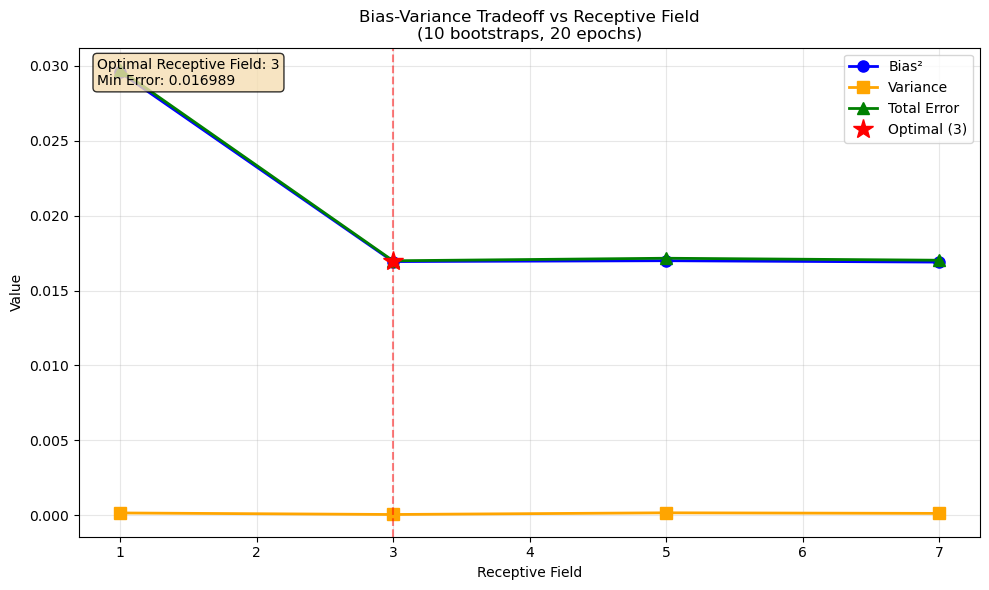


 Optimal receptive_field: 3
  Bias²: 0.016937
  Variance: 0.000052
  Error: 0.016989

----------------------------------------
Pausing for 10 seconds to clear memory...
----------------------------------------

TEST 2/2: ACTIVATION
TESTING: ACTIVATION
Values: ['relu', 'leaky_relu', 'elu']
Bootstraps: 10, Epochs: 20
Using 8/12 test samples for predictions

--- activation = relu (1/3) ---
  Bootstrap 1/10...
  Error in bootstrap 1: create_simple_CNN_model() missing 1 required posit...


UnboundLocalError: cannot access local variable 'model' where it is not associated with a value

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
import tensorflow as tf
import gc
import time
import warnings
warnings.filterwarnings('ignore')

BOOTSTRAP_RUNS = 10      
EPOCHS = 20             
BATCH_SIZE = 4

TEST_SEQUENCE = [
    {
        'name': 'receptive_field',
        'values': [1, 3, 5, 7],
        'fixed_params': {"n_layers": 2, "n_filters": 64, "eta": 1e-3, "lmbd": 1e-5,
                          "activation": "relu", "padding": "same", "regularizer": "l2",
                          "optimizer_name": "adam", "loss_function='weighted_bce"}  
    },
]

all_results_1, optimal_values_1 = run_complete_analysis()

MEMORY-OPTIMIZED BIAS-VARIANCE ANALYSIS
Dataset size: 46 training, 12 test
Configuration: 10 bootstraps, 20 epochs
Test sequence: ['activation', 'eta']

Estimated time: ~13.3 hours
Start time: 16:53:36

TEST 1/2: ACTIVATION
TESTING: ACTIVATION
Values: ['relu', 'leaky_relu', 'elu']
Bootstraps: 10, Epochs: 20
Using 8/12 test samples for predictions

--- activation = relu (1/3) ---
  Bootstrap 1/10...WARNING:tensorflow:From C:\Users\chery\anaconda3\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

 (519.4s, ~77.9min remaining)
  Bootstrap 2/10... (541.5s, ~70.7min remaining)
  Bootstrap 3/10... (514.1s, ~61.3min remaining)
  Bootstrap 4/10... (514.5s, ~52.2min remaining)
  Bootstrap 5/10... (511.9s, ~43.4min remaining)
  Bootstrap 6/10... (464.0s, ~34.1min remaining)
  Bootstrap 7/10... (408.5s, ~24.8min remaining)
  Bootstrap 8/10... (405.3s, ~16.2min remaining)
  Bootstrap 9

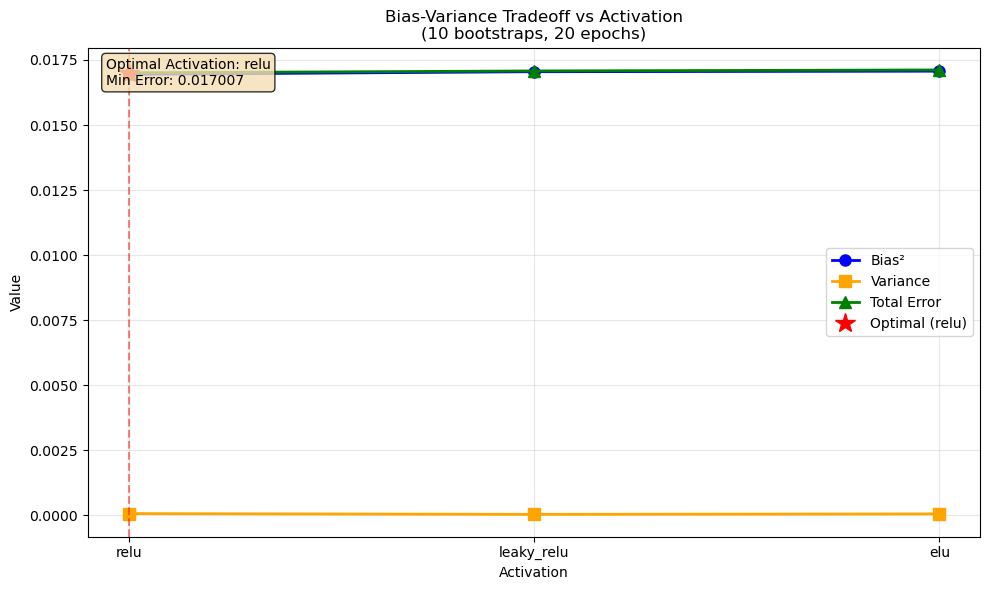


 Optimal activation: relu
  Bias²: 0.016948
  Variance: 0.000059
  Error: 0.017007

----------------------------------------
Pausing for 10 seconds to clear memory...
----------------------------------------

TEST 2/2: ETA
Using optimal activation = relu from previous test
TESTING: ETA
Values: [1e-05, 3e-05, 0.0001, 0.0003, 0.001]
Bootstraps: 10, Epochs: 20
Using 8/12 test samples for predictions

--- eta = 1e-05 (1/5) ---
  Bootstrap 1/10... (398.9s, ~59.8min remaining)
  Bootstrap 2/10... (400.4s, ~53.3min remaining)
  Bootstrap 3/10... (396.3s, ~46.5min remaining)
  Bootstrap 4/10... (396.4s, ~39.8min remaining)
  Bootstrap 5/10... (417.4s, ~33.5min remaining)
  Bootstrap 6/10... (492.2s, ~27.8min remaining)
  Bootstrap 7/10... (449.1s, ~21.1min remaining)
  Bootstrap 8/10... (474.3s, ~14.3min remaining)
  Bootstrap 9/10... (486.9s, ~7.2min remaining)
  Bootstrap 10/10... (491.4s, ~0.0min remaining)
  Results: Bias²=0.167032, Variance=0.001035, Error=0.168067
  Successful bootstrap

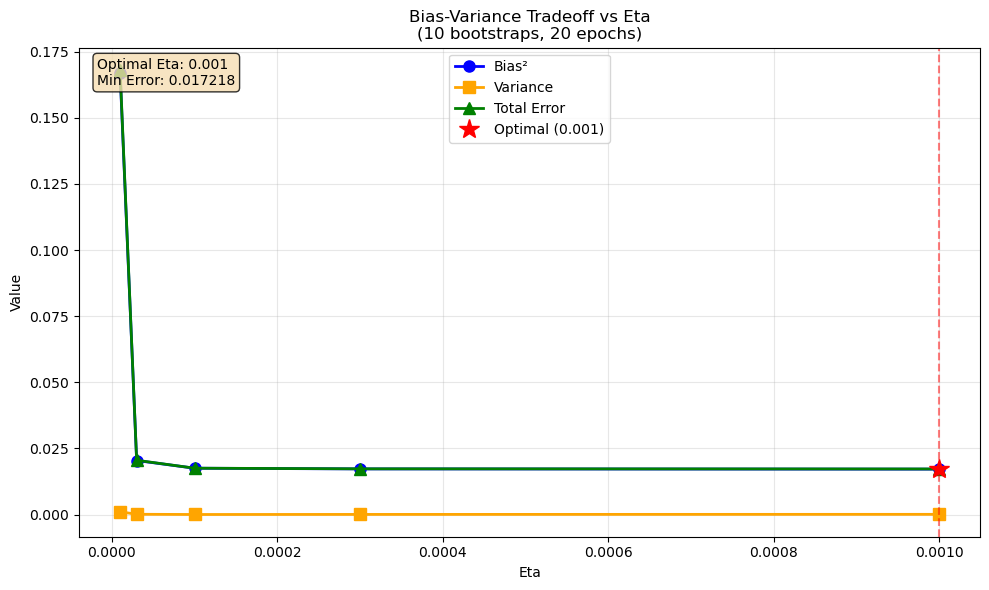


 Optimal eta: 0.001
  Bias²: 0.017154
  Variance: 0.000064
  Error: 0.017218
ANALYSIS COMPLETE!
End time: 02:42:37

OPTIMAL HYPERPARAMETERS FOUND:
----------------------------------------
activation      = relu
eta             = 0.001

 Optimal parameters saved to 'optimal_hyperparameters.txt'
SUMMARY FILES:
CSV files:
  activation_bias_variance_10bootstraps.csv
  eta_bias_variance_10bootstraps.csv

Plot files:
  activation_bias_variance.png
  eta_bias_variance.png


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
import tensorflow as tf
import gc
import time
import warnings
warnings.filterwarnings('ignore')

BOOTSTRAP_RUNS = 10      
EPOCHS = 20             
BATCH_SIZE = 4

TEST_SEQUENCE = [
    {
        'name': 'activation',
        'values': ["relu", "leaky_relu", "elu"],
        'fixed_params': {"n_layers": 2, "n_filters": 64,  
            "receptive_field": 3,
            "eta": 1e-3,
            "lmbd": 1e-5,
            "activation": "relu",
            "padding": "same",
            "regularizer": "l2",
            "optimizer_name": "adam",
            "loss_function='weighted_bce"}  
    },
    {
        'name': 'eta',
        'values': [1e-5, 3e-5, 1e-4, 3e-4, 1e-3],
        'fixed_params': {"n_layers": 2, "n_filters": 64,  
            "receptive_field": 3,
            "activation": "relu",
            "lmbd": 1e-5,
            "activation": "relu",
            "padding": "same",
            "regularizer": "l2",
            "optimizer_name": "adam",
            "loss_function='weighted_bce"} 
    },
]

all_results_2, optimal_values_2 = run_complete_analysis()